# chunk analyse

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
BASE_DIR = "files"
SAMPLE_XLSX = f"{BASE_DIR}/chunk-sample.csv"
CHUNK_GAS_LATENCY = f"{BASE_DIR}/chunk-gas-latency.csv"

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

In [5]:
def get_sample_df(f: str):
  df = pd.read_csv(f)
  return df
sample_df = get_sample_df(SAMPLE_XLSX)

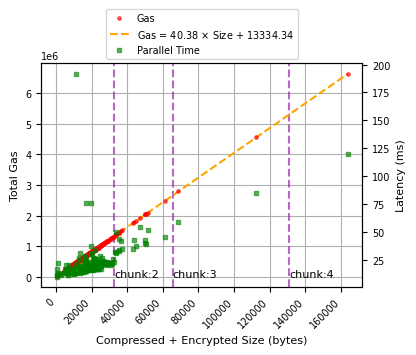

Linear model: y = 40.375988x + 13334.34


In [6]:
def get_chunk_sample(df):
    """
    df 必须包含：
    - tex_size_kb
    - total_gas
    - latency
    - chunk_count
    """

    # 排序（按 tex size）
    df = df.sort_values("total_bytes")

    fig, ax1 = plt.subplots(figsize=(4.2, 3.6))

    # 左轴：Gas
    ax1.set_xlabel("Compressed + Encrypted Size (bytes)")
    ax1.set_ylabel("Total Gas")

    line1 = 2**15
    line2 = 2**16
    line3 = 2**17
    ax1.axvline(line1, linestyle='--', color='#9C27B0', alpha=0.7)
    ax1.text(line1, 1000, "chunk:2")
    ax1.axvline(line2, linestyle='--', color='#9C27B0', alpha=0.7)
    ax1.text(line2, 1000, "chunk:3")
    ax1.axvline(line3, linestyle='--', color='#9C27B0', alpha=0.7)
    ax1.text(line3, 1000, "chunk:4")


    ax1.scatter(
        df["total_bytes"],
        df["total_gas"],
        s=6,
        marker="o",
        c="red",
        alpha=0.6,
        zorder=500,
        label="Gas"
    )
    
    ax1.set_xticks(ax1.get_xticks())
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

    # 右轴：Latency
    ax2 = ax1.twinx()
    ax2.set_ylabel("Latency (ms)")

    ax2.scatter(
        df["total_bytes"],
        df["upload_time_ms"],
        s=5,
        c="green",
        marker="s",
        alpha=0.6,
        label="Parallel Time"
    )

    x = df["total_bytes"].values
    y = df["total_gas"].values
    a, b = np.polyfit(x, y, 1)
    x_line = np.linspace(0, x.max(), 100)
    y_line = a * x_line + b
    ax1.plot(
        x_line,
        y_line,
        # linewidth=1,
        linestyle="--",
        c="orange",
        label=fr"Gas = {a:.2f} $\times$ Size + {b:.2f}"
    )

    # 合并 legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="lower center",
        bbox_to_anchor=(0.5, 1)
    )

    ax1.grid(True)

    plt.tight_layout()
    plt.show()
    print(f"Linear model: y = {a:.6f}x + {b:.2f}")
get_chunk_sample(sample_df)

## chunk size experiment

In [7]:
def get_chunk_df(f: str):
    df = pd.read_csv(f)
    return df.groupby(df['chunkSize']).agg({
        'totalGas': ['mean','median'],
        'seriesTime': ['mean','median'],
        'parallelTime': ['mean','median'],
    })
chunk_df = get_chunk_df(CHUNK_GAS_LATENCY)

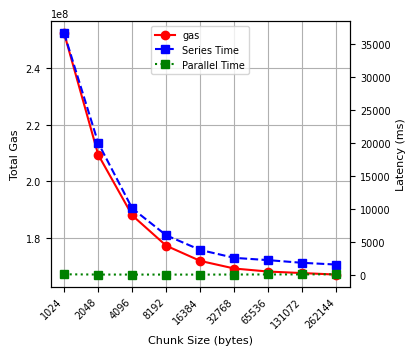

In [8]:
def chunk_gas_latency(df):
    fig, ax1 = plt.subplots(figsize=(4.2, 3.6))

    # 使用位置索引作为 x 轴（0, 1, 2, 3, ...）
    x_positions = range(len(df.index))
    
    # 左轴：Gas
    ax1.set_xlabel("Chunk Size (bytes)")
    ax1.set_ylabel("Total Gas")

    # 用位置索引绘图
    ax1.plot(x_positions, df["totalGas"]["mean"], marker='o', c="r", label="gas")

    # 设置 x 轴刻度为所有位置
    ax1.set_xticks(x_positions)
    # 标签用实际的 chunkSize 值
    ax1.set_xticklabels(df.index, rotation=45, ha='right')

    # 右轴：Latency
    ax2 = ax1.twinx()
    ax2.set_ylabel("Latency (ms)")

    # 同样用位置索引绘图
    ax2.plot(x_positions, df["seriesTime"]["mean"], linestyle="--", marker='s',  c="blue", label="Series Time")
    ax2.plot(x_positions, df["parallelTime"]["mean"], linestyle=":", marker='s',  c="green", label="Parallel Time")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center")

    ax1.grid(True)

    plt.tight_layout()
    plt.show()
chunk_gas_latency(chunk_df)

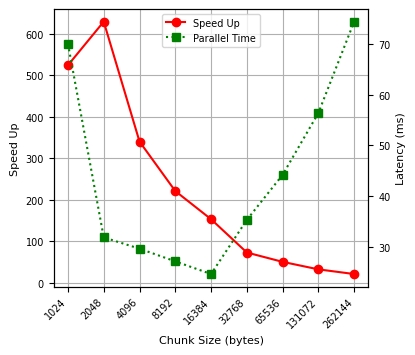

In [9]:
def speed_up(df):
    df["speedup"] = df["seriesTime"]["mean"] / df["parallelTime"]["mean"]
    fig, ax1 = plt.subplots(figsize=(4.2, 3.6))

    x_positions = range(len(df.index))
    
    # 左轴：Gas
    ax1.set_xlabel("Chunk Size (bytes)")
    ax1.set_ylabel("Speed Up")

    # 用位置索引绘图
    ax1.plot(x_positions, df["speedup"], marker='o', c="r", label="Speed Up")

    # 设置 x 轴刻度为所有位置
    ax1.set_xticks(x_positions)
    # 标签用实际的 chunkSize 值
    ax1.set_xticklabels(df.index, rotation=45, ha='right')

    # 右轴：Latency
    ax2 = ax1.twinx()
    ax2.set_ylabel("Latency (ms)")

    # 同样用位置索引绘图
    ax2.plot(x_positions, df["parallelTime"]["mean"], linestyle=":", marker='s',  c="green", label="Parallel Time")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center")

    ax1.grid(True)

    plt.tight_layout()
    plt.show()
speed_up(chunk_df)